In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

import scipy.integrate as integrate
from scipy import spatial

from matplotlib.patches import Circle

from astropy.cosmology import FlatLambdaCDM

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
if size == 'big':
    par.files.partfile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
    par.files.halofile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
elif size == 'small':
    par.files.halofile_in = "/home/jamesdr/scratch/smallbox/output_00011"
    par.files.partfile_in = "/home/jamesdr/scratch/smallbox/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size)
par.files.halofile_out = "/home/jamesdr/usrp2024/{}_{}/halofile_out.std".format(comp,size)

Found 134217728 particles


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/{}box/)'.format(size), par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
from baryonification.baryonification.io import read_nbody_file

In [6]:
p_header, non_displaced_dm = read_nbody_file(par)

Found 134217728 particles


In [7]:
if comp == 'multicomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #gas
        p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
        p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
        #stars
        p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
        p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

        #convert to Mpc/h
        p_gas['x']=Lbox*(p_gas['x']+0.5)
        p_gas['y']=Lbox*(p_gas['y']+0.5)
        p_gas['z']=Lbox*(p_gas['z']+0.5)
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)
        p_star['x']=Lbox*(p_star['x']+0.5)
        p_star['y']=Lbox*(p_star['y']+0.5)
        p_star['z']=Lbox*(p_star['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
        p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
    
        #split particles into chunks
        p_gas_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                    p_gas_list += [p_gas[ID_gas]]
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
                
        #split particles into chunks
        p_star_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                    p_star_list += [p_star[ID_star]]
   
        pl = 0
        for pp in p_gas_list:
            pl += len(pp)
        if (pl != len(p_gas)):
            print('Chunking: particle number not conserved! Exit.')
            exit()

        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        pl = 0
        for pp in p_star_list:
            pl += len(pp)
        if (pl != len(p_star)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_gas_list, p_dm_list, p_star_list
    
elif comp == 'singlecomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')

        #convert to Mpc/h
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_dm['mass']))
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
   
        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_dm_list

In [8]:
if comp=='multicomp':    
    p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))
elif comp=='singlecomp':
    p_displaced_header, displaced_dm = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))

Om =  0.27524456
Reading tipsy-file done!


In [9]:
from baryonification.baryonification.io import read_halo_file
haloes = read_halo_file(par)

Found 132551 clumps
Converting r200b, M200b, and c200b to r200c, M200c, and c200c


/home/jamesdr/.conda/envs/usrp2024/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Done!


In [11]:
displaced_dm_tree = spatial.cKDTree(list(zip(displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])), leafsize=100, boxsize = unit_l_in_Mpc_per_h)
gas_tree = spatial.cKDTree(list(zip(displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])), leafsize=100, boxsize = unit_l_in_Mpc_per_h)

NameError: name 'rbuffer' is not defined

In [14]:
halo_tree = spatial.cKDTree(list(zip(haloes[0]['x']+10.0,haloes[0]['y']+10.0,haloes[0]['z']+10.0)), leafsize=100, boxsize = unit_l_in_Mpc_per_h+20.0)

In [15]:
#Now we take the largest halo, compute the SZ signal, turn it to a function of distance from halo center, and plot it

N = 20
bins=1000

sorted_halo_index = np.argsort(haloes[0]['Mvir'])

top = sorted_halo_index[-N :]

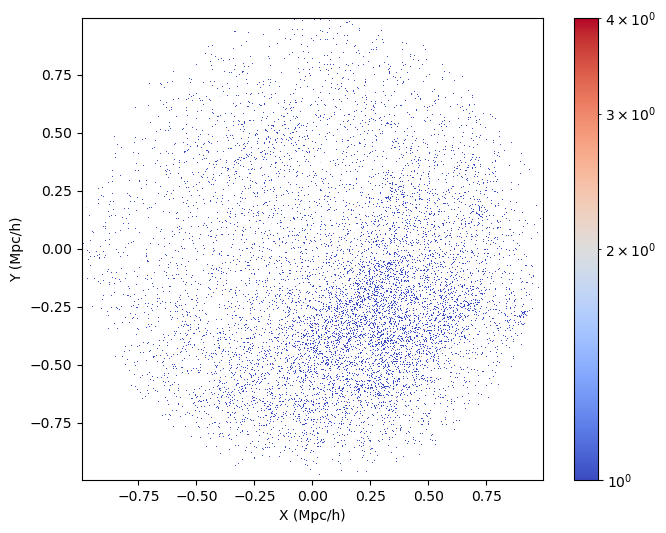

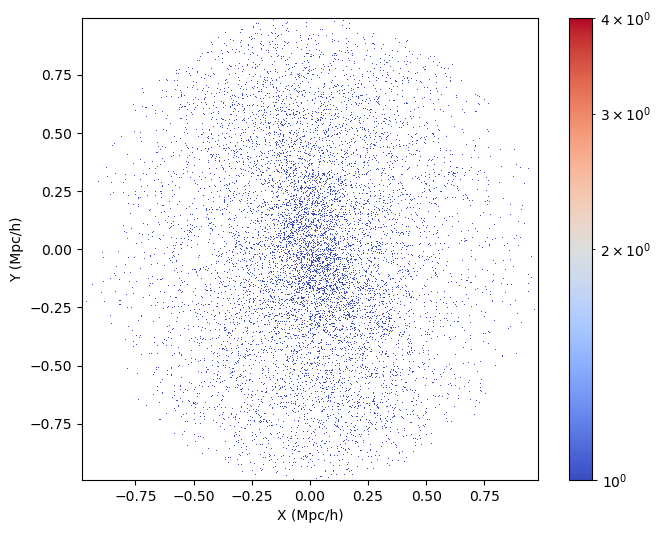

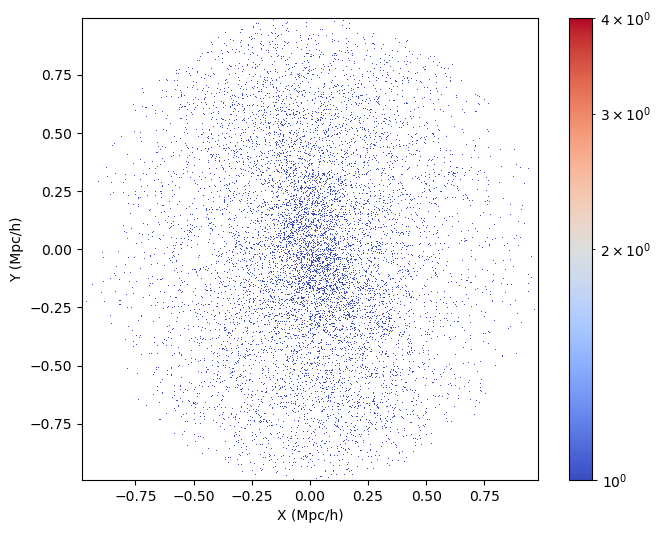

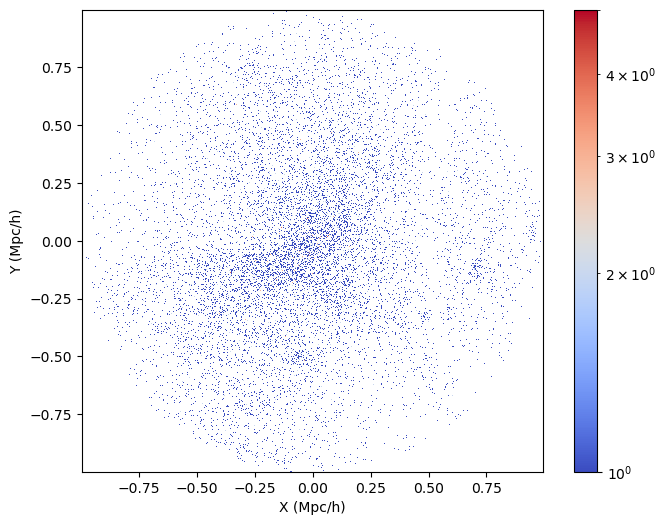

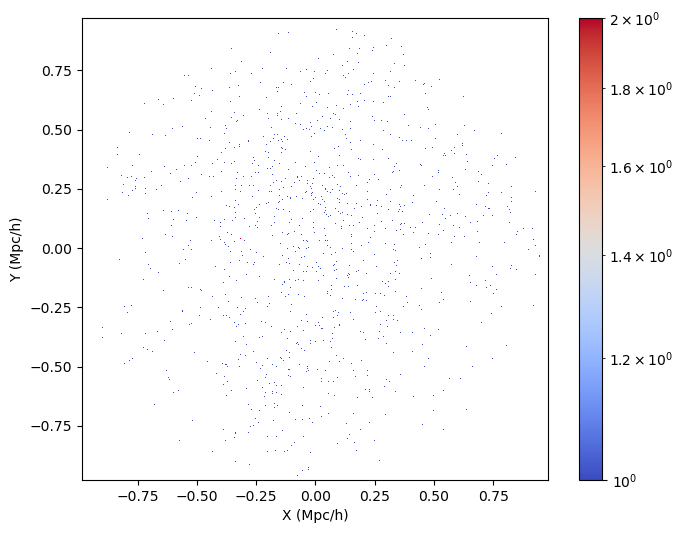

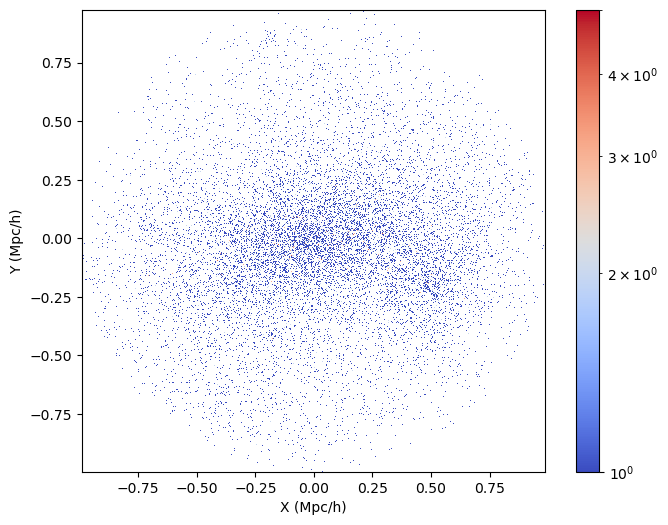

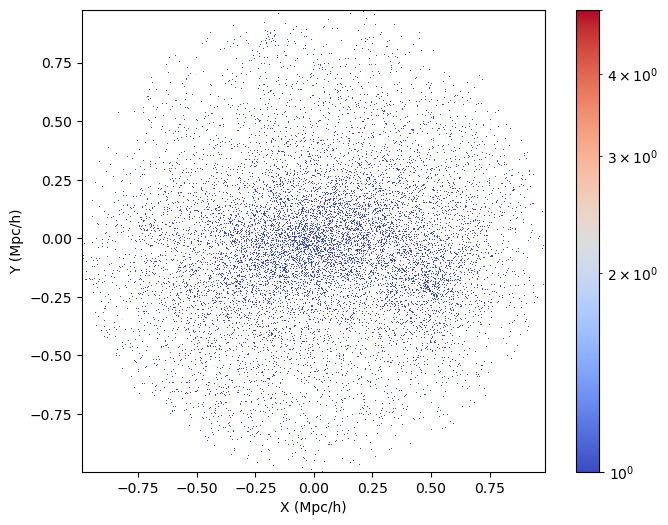

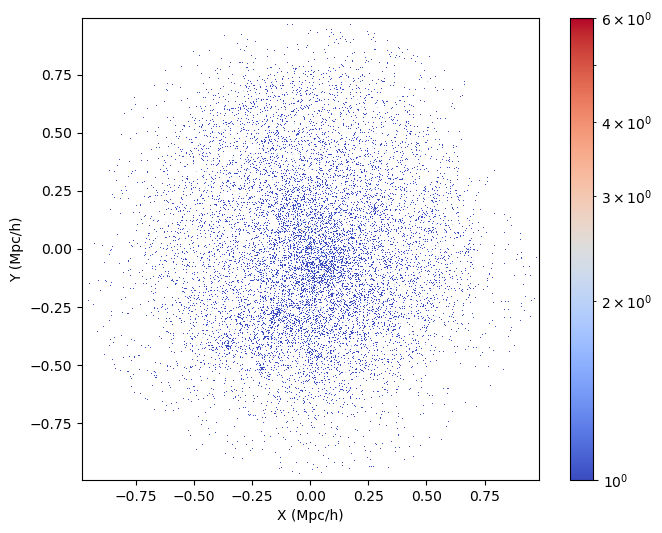

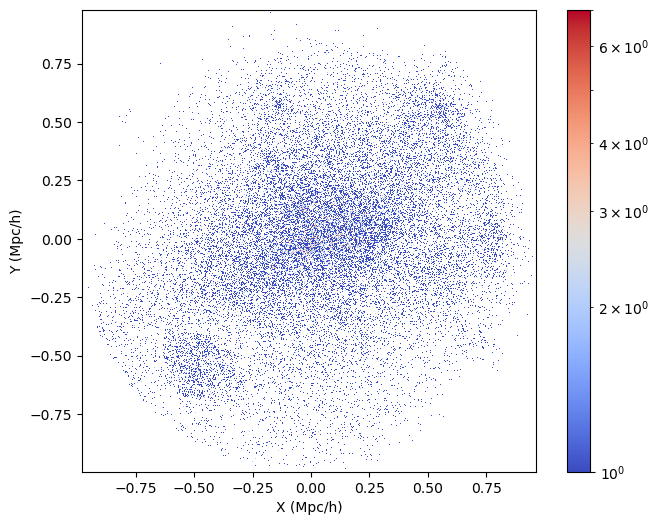

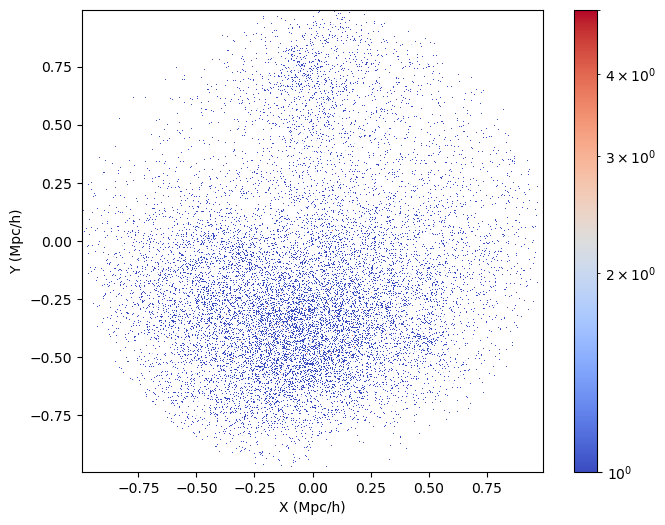

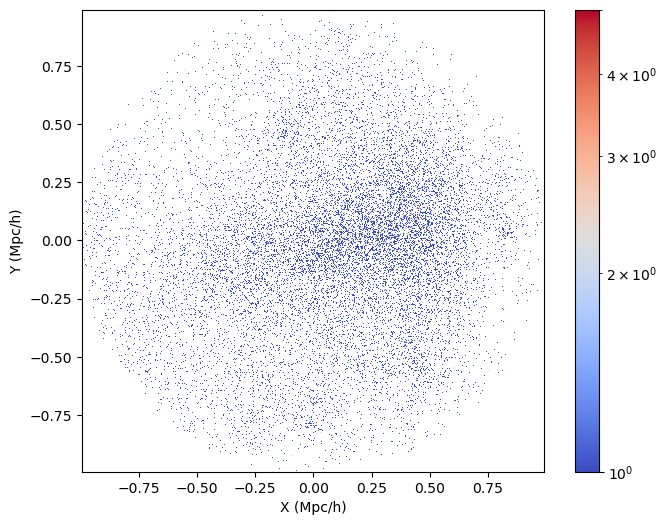

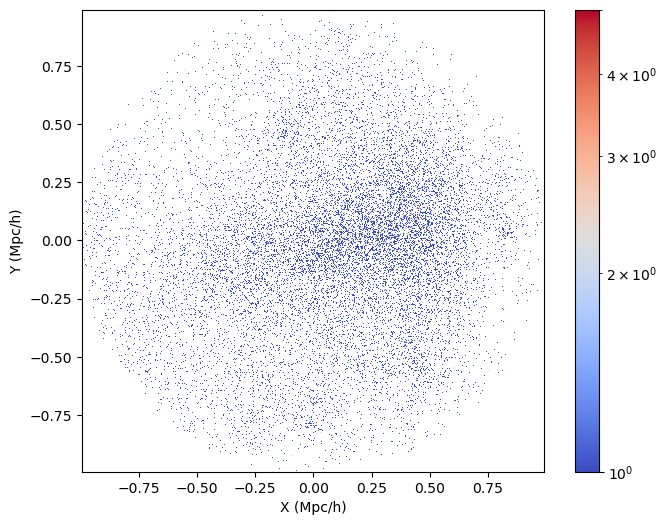

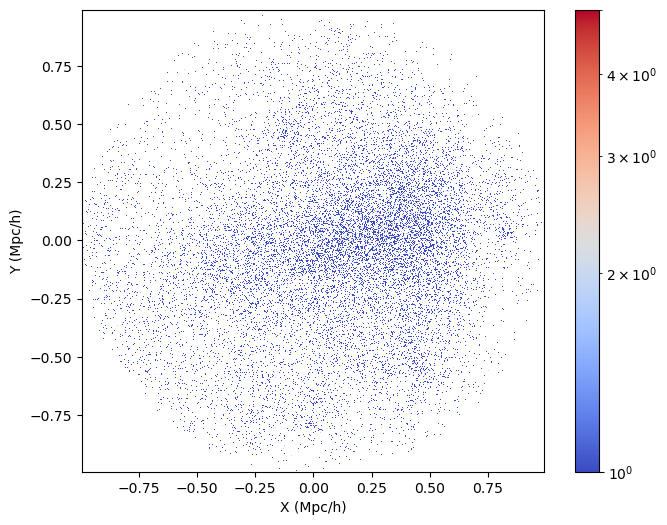

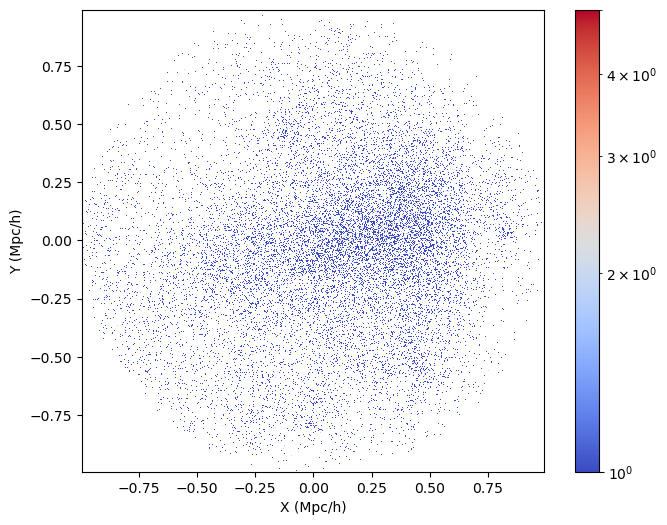

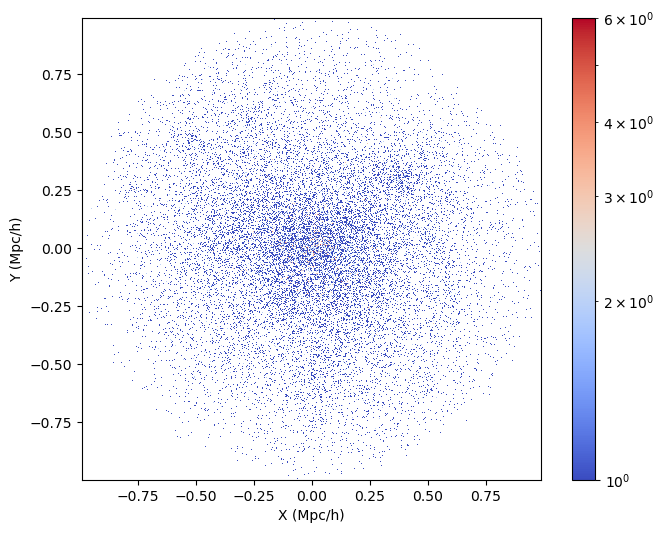

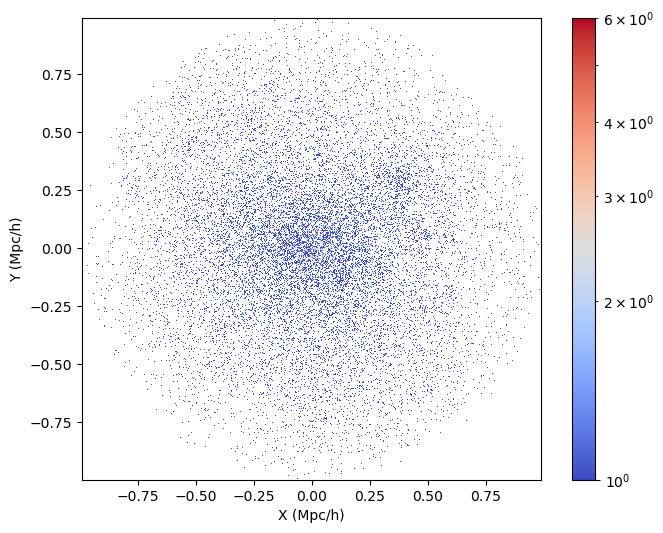

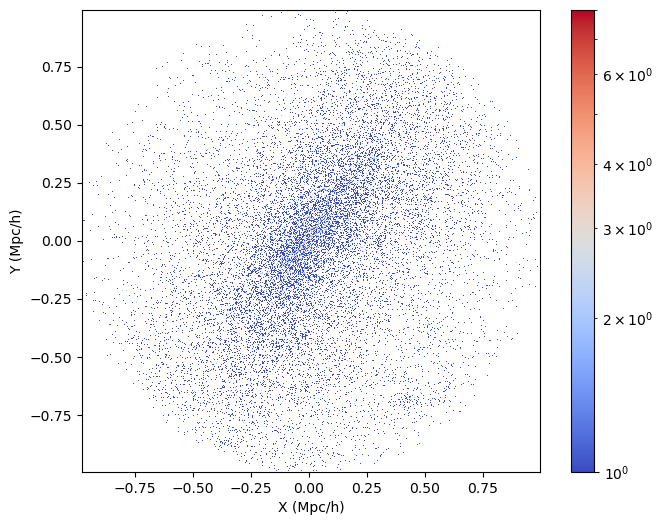

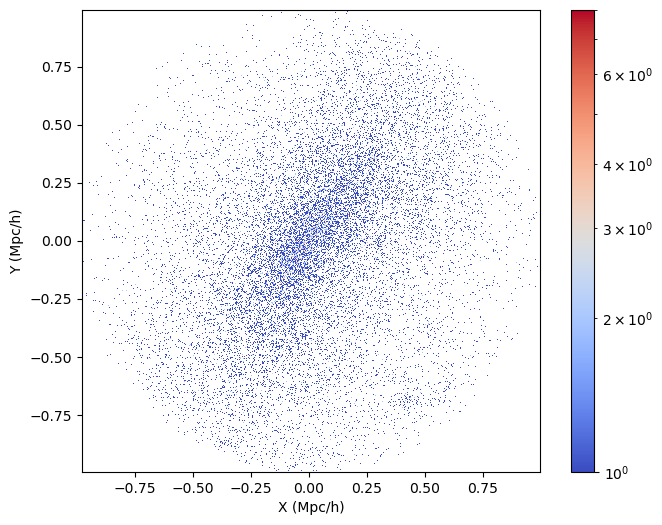

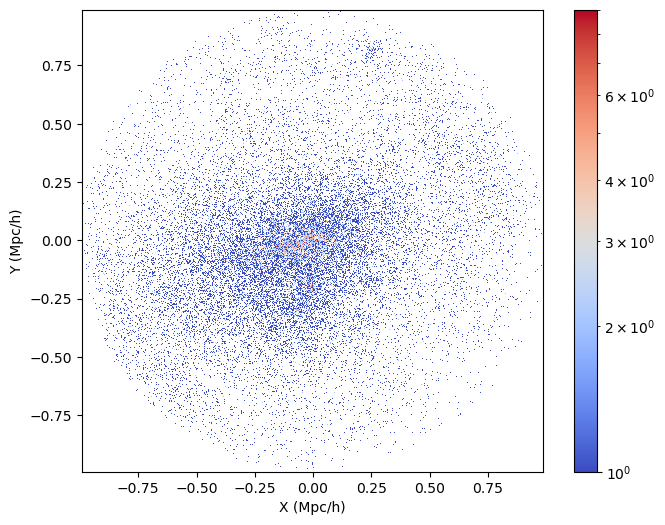

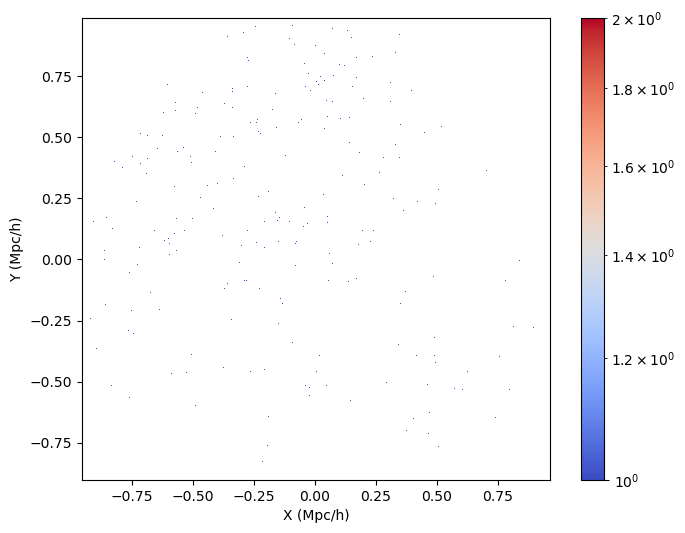

In [16]:
halo_profile = np.zeros((bins, bins, N))

for i in range(N):
    Lbox = unit_l_in_Mpc_per_h
    #We consider one halo at a time
    idhost = top[i]
    ID = gas_tree.query_ball_point((haloes[0]['x'][idhost],haloes[0]['y'][idhost],haloes[0]['z'][idhost]), haloes[0]['rvir'][idhost]) 
    norm_x = displaced_gas[0]['x'][ID]-haloes[0]['x'][idhost]
    norm_y = displaced_gas[0]['y'][ID]-haloes[0]['y'][idhost]
    norm_z = displaced_gas[0]['z'][ID]-haloes[0]['z'][idhost]
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -Lbox/2.0:
            norm_x[j] += Lbox
        elif norm_x[j] > Lbox/2.0:
            norm_x[j] -= Lbox
    for j in range(len(norm_y)):
        if norm_y[j] < -Lbox/2.0:
            norm_y[j] += Lbox
        elif norm_y[j] > Lbox/2.0:
            norm_y[j] -= Lbox

    norm_x = norm_x/haloes[0]['rvir'][idhost]
    norm_y = norm_y/haloes[0]['rvir'][idhost]
    norm_z = norm_z/haloes[0]['rvir'][idhost]
    

    #We develop a histogram
    #weights[iphalo==itest]*haloes[0]['vz'][itest]
    hist, xedges, yedges = np.histogram2d(norm_x, norm_y,bins=bins)
    hist=hist.T
    
    norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(hist), vmax=np.max(hist))
    
    plt.figure(figsize=(8, 6))
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm='log', cmap='coolwarm')
    
    # Add colorbar
    plt.colorbar()
    
    # Adding labels and title
    plt.xlabel('X (Mpc/h)')
    plt.ylabel('Y (Mpc/h)')

    plt.show()
    halo_profile[:,:,i] += hist

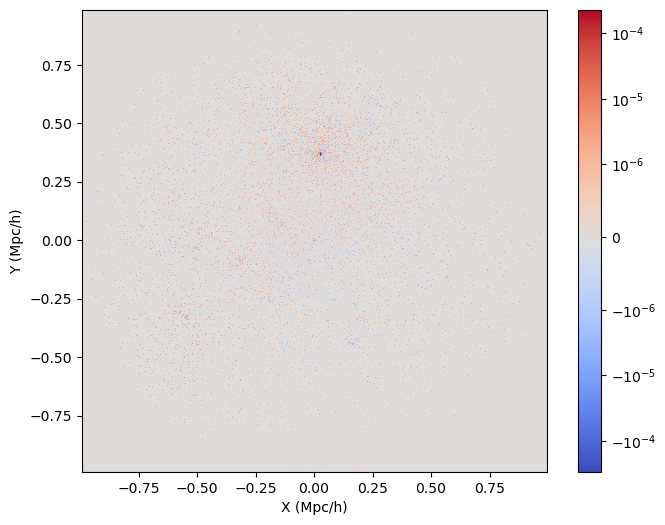

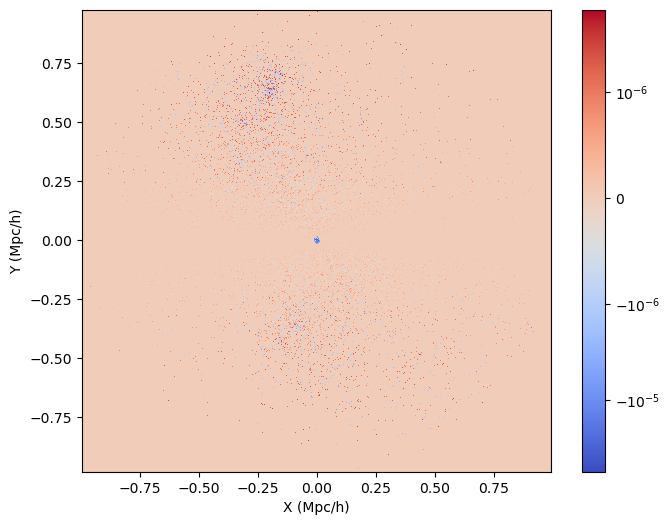

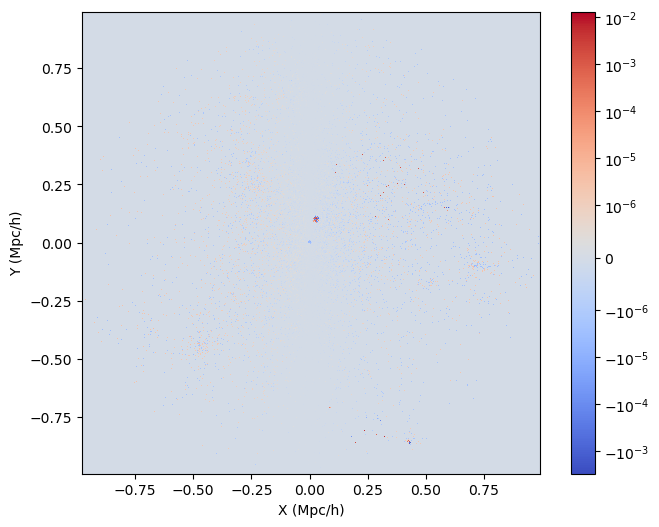

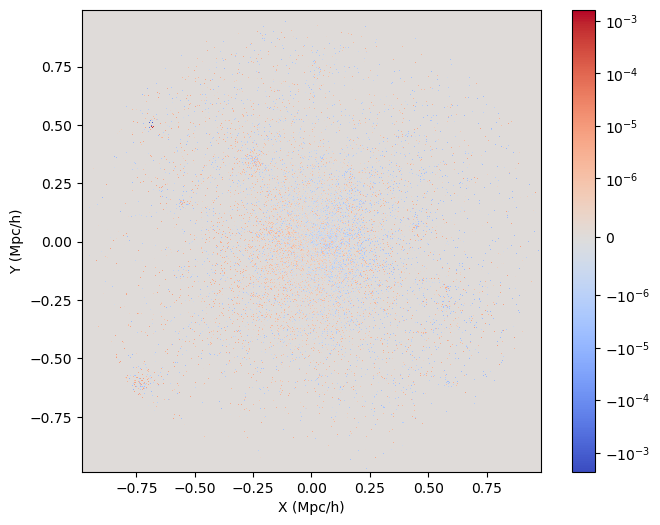

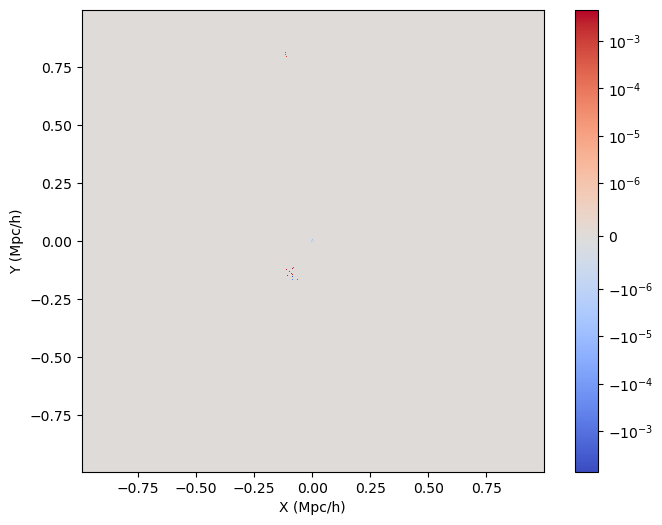

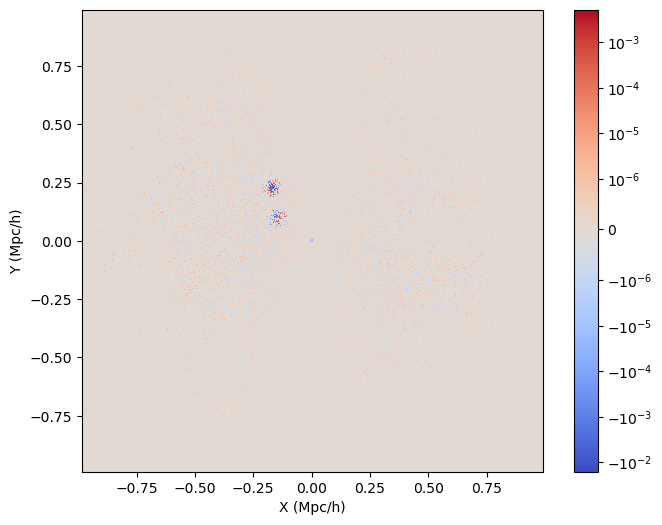

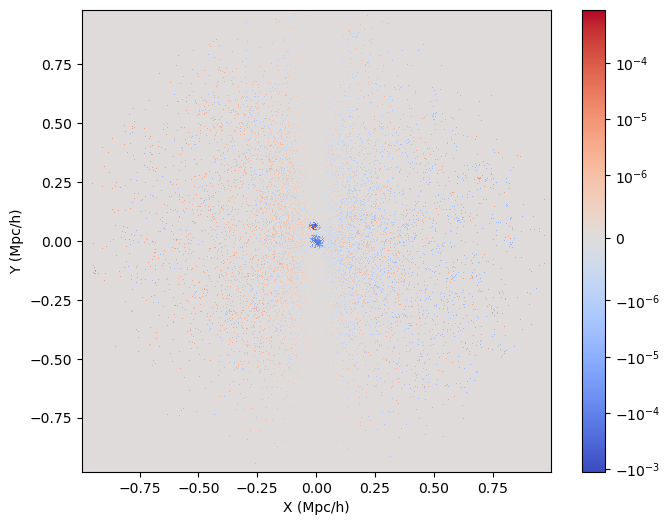

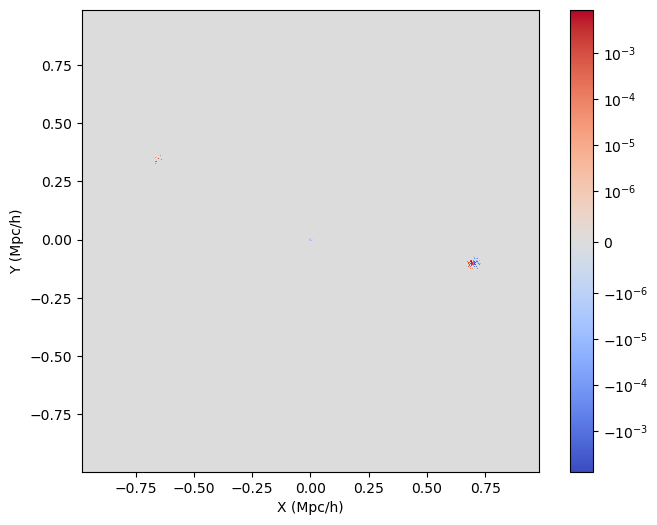

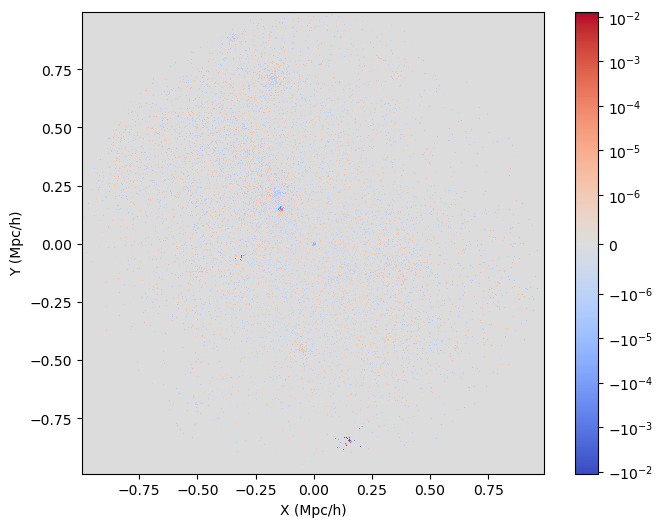

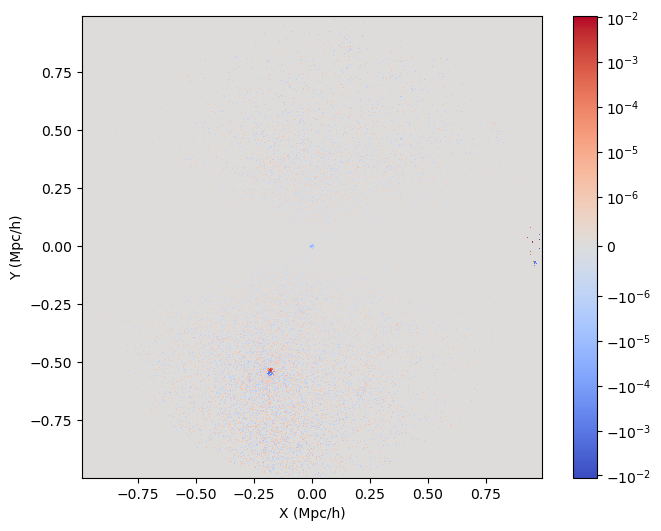

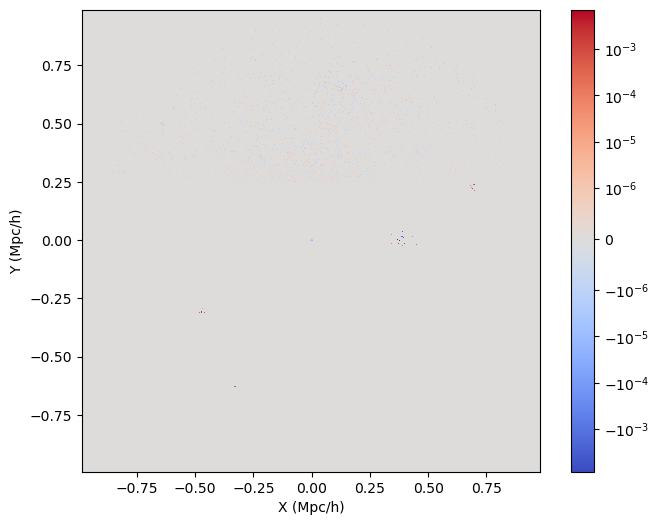

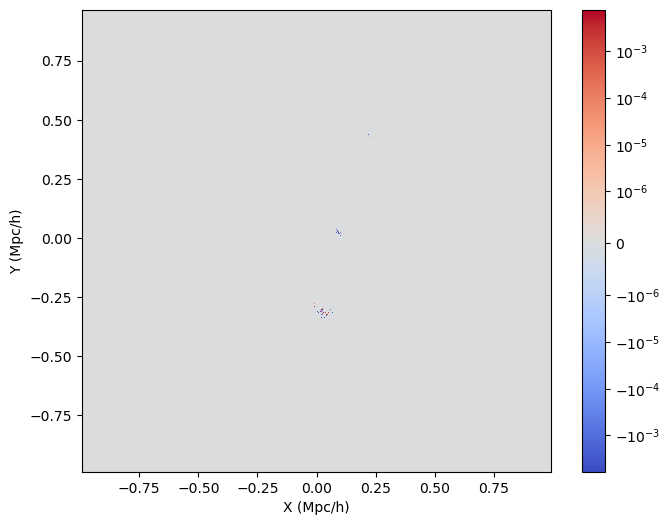

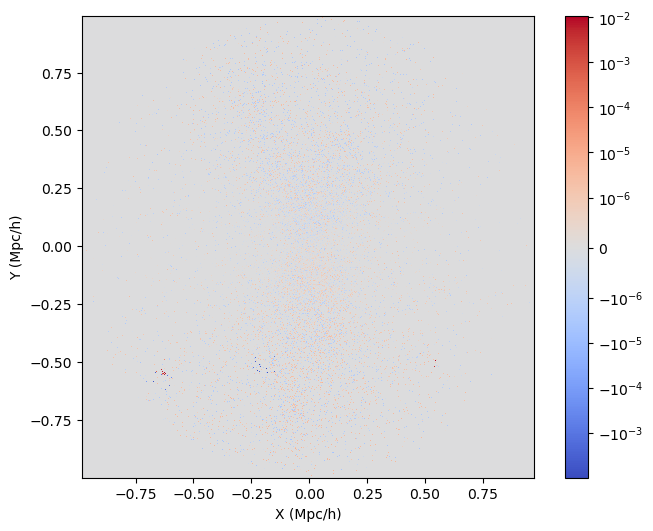

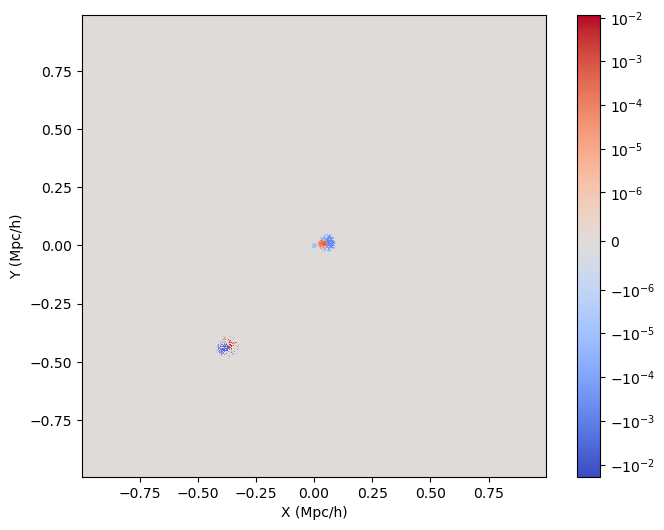

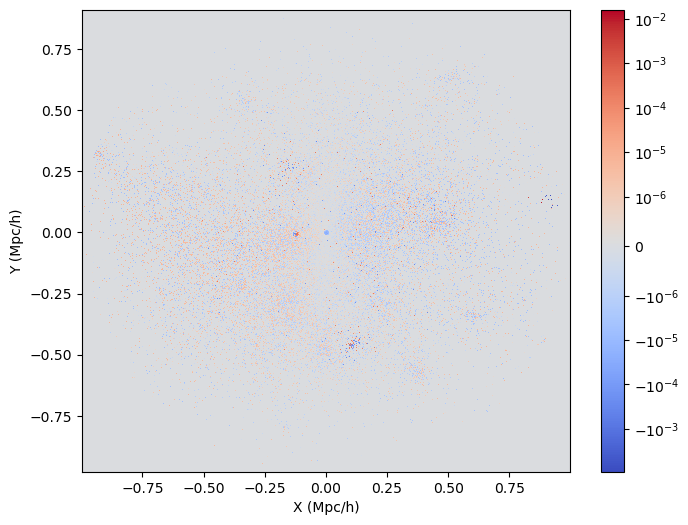

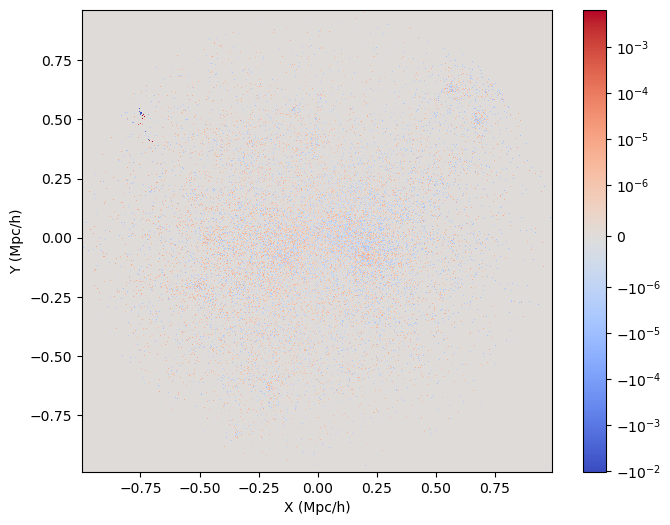

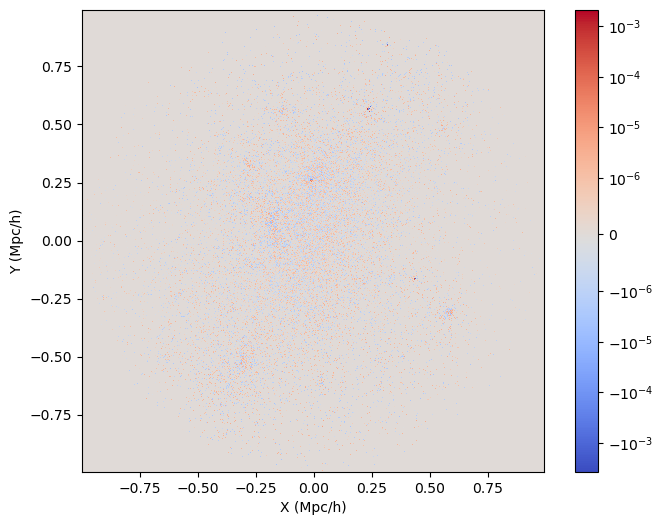

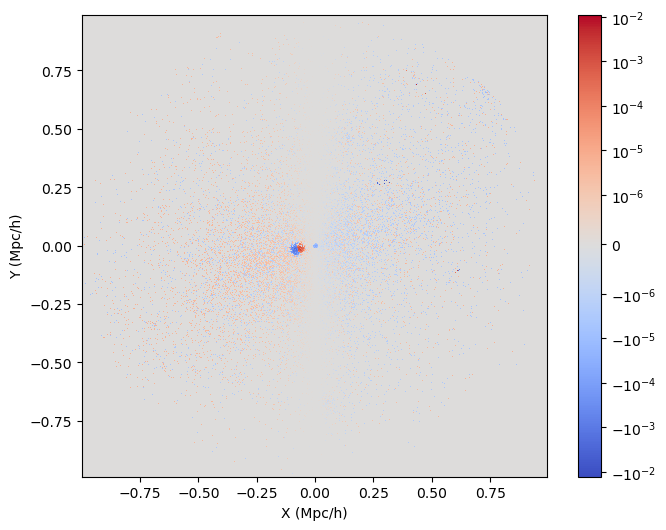

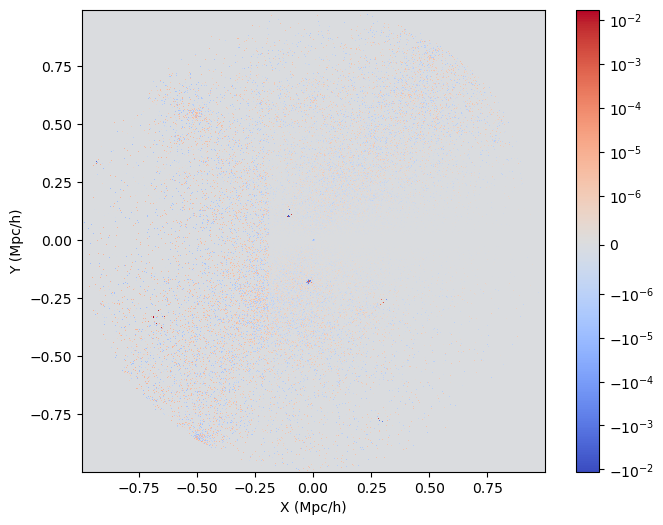

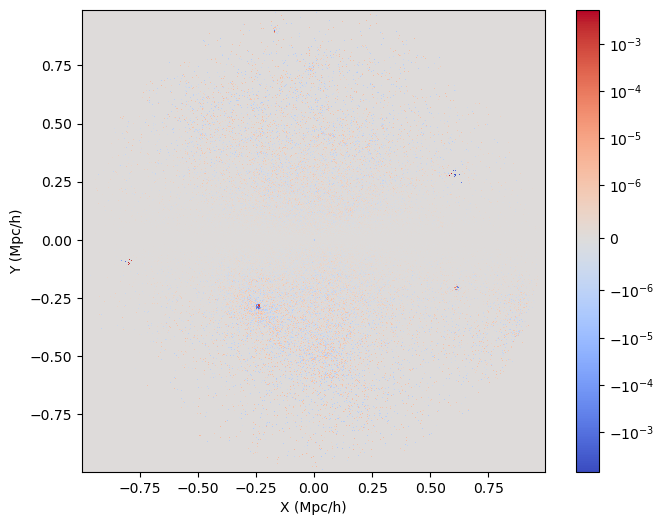

In [16]:
halo_profile = np.zeros((bins, bins, N))

for i in range(N):
    Lbox = unit_l_in_Mpc_per_h
    #We consider one halo at a time
    idhost = top[i]
    ID = displaced_dm_tree.query_ball_point((haloes[0]['x'][idhost],haloes[0]['y'][idhost],haloes[0]['z'][idhost]), haloes[0]['rvir'][idhost]) 
    norm_x = displaced_dm[0]['x'][ID]-haloes[0]['x'][idhost]
    norm_y = displaced_dm[0]['y'][ID]-haloes[0]['y'][idhost]
    norm_z = displaced_dm[0]['z'][ID]-haloes[0]['z'][idhost]
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -Lbox/2.0:
            norm_x[j] += Lbox
        elif norm_x[j] > Lbox/2.0:
            norm_x[j] -= Lbox
    for j in range(len(norm_y)):
        if norm_y[j] < -Lbox/2.0:
            norm_y[j] += Lbox
        elif norm_y[j] > Lbox/2.0:
            norm_y[j] -= Lbox

    norm_x = norm_x/haloes[0]['rvir'][idhost]
    norm_y = norm_y/haloes[0]['rvir'][idhost]
    norm_z = norm_z/haloes[0]['rvir'][idhost]
    
    displacement_field_x = displaced_dm[0]['x'][ID] - non_displaced_dm[0]['x'][ID]
    displacement_field_y = displaced_dm[0]['y'][ID] - non_displaced_dm[0]['y'][ID]
    displacement_field_z = displaced_dm[0]['z'][ID] - non_displaced_dm[0]['z'][ID]
    
    dot_product = (norm_x * displacement_field_x) + (norm_y * displacement_field_y) + (norm_z * displacement_field_z)

    #We develop a histogram
    #weights[iphalo==itest]*haloes[0]['vz'][itest]
    hist, xedges, yedges = np.histogram2d(norm_x, norm_y,bins=bins,density=False,weights=dot_product)
    hist=hist.T
    
    norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(hist), vmax=np.max(hist))
    
    plt.figure(figsize=(8, 6))
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='coolwarm')
    
    # Add colorbar
    plt.colorbar()
    
    # Adding labels and title
    plt.xlabel('X (Mpc/h)')
    plt.ylabel('Y (Mpc/h)')

    plt.show()
    halo_profile[:,:,i] += hist